In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
df=pd.read_csv('/content/forwards_dataset (1).csv')
df

,player_name,age,nationality,club,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,goals,assists,shots_on_target,conversion_rate,transfer_risk_level
0,Kylian Mbappé,25.0,France,Real Madrid,91.0,92,193M,2.0,3,28,27,16,38,71.1,Low
1,Erling Haaland,25.0,Norway,Manchester City,75.0,93,164M,4.0,1,15,17,4,58,29.3,Low
2,Vinicius Jr,25.0,Brazil,Real Madrid,75.0,92,184M,NaN,1,25,22,13,88,25.0,Low
3,Lionel Messi,25.0,Argentina,Inter Miami,75.0,91,11M,5.0,3,40,9,16,71,12.7,High
4,Cristiano Ronaldo,25.0,Portugal,Al Nassr,NaN,89,4M,1.0,6,33,9,12,75,12.0,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Hwang Boateng,NaN,South Korea,Lyon,66.0,67,15M,2.0,1,14,19,9,17,111.8,Low
2996,Mason Williams,33.0,USA,Villarreal,80.0,80,8M,2.0,2,15,30,15,39,76.9,High
2997,Carlos Lopez,21.0,Egypt,Torino,75.0,77,16M,1.0,0,33,1,15,84,1.2,High
2998,Kwame Mensah,27.0,Switzerland,Galatasaray,86.0,86,35M,2.0,0,42,5,17,76,6.6,High


In [ ]:
df.shape

(3000, 15)

In [ ]:
df.head()

,player_name,age,nationality,club,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,goals,assists,shots_on_target,conversion_rate,transfer_risk_level
0,Kylian Mbappé,25.0,France,Real Madrid,91.0,92,193M,2.0,3,28,27,16,38,71.1,Low
1,Erling Haaland,25.0,Norway,Manchester City,75.0,93,164M,4.0,1,15,17,4,58,29.3,Low
2,Vinicius Jr,25.0,Brazil,Real Madrid,75.0,92,184M,NaN,1,25,22,13,88,25.0,Low
3,Lionel Messi,25.0,Argentina,Inter Miami,75.0,91,11M,5.0,3,40,9,16,71,12.7,High
4,Cristiano Ronaldo,25.0,Portugal,Al Nassr,NaN,89,4M,1.0,6,33,9,12,75,12.0,High


In [ ]:
df.tail()

,player_name,age,nationality,club,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,goals,assists,shots_on_target,conversion_rate,transfer_risk_level
2995,Hwang Boateng,NaN,South Korea,Lyon,66.0,67,15M,2.0,1,14,19,9,17,111.8,Low
2996,Mason Williams,33.0,USA,Villarreal,80.0,80,8M,2.0,2,15,30,15,39,76.9,High
2997,Carlos Lopez,21.0,Egypt,Torino,75.0,77,16M,1.0,0,33,1,15,84,1.2,High
2998,Kwame Mensah,27.0,Switzerland,Galatasaray,86.0,86,35M,2.0,0,42,5,17,76,6.6,High
2999,Yusuf Williams,24.0,South Korea,Newcastle,75.0,76,16M,3.0,4,10,31,4,75,41.3,Low


In [ ]:
df.dtypes

,0
player_name,object
age,float64
nationality,object
club,object
overall_rating,float64
potential_rating,int64
market_value_million_eur,object
contract_years_left,float64
injury_history,int64
matches_played,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_name               3000 non-null   object 
 1   age                       2955 non-null   float64
 2   nationality               3000 non-null   object 
 3   club                      3000 non-null   object 
 4   overall_rating            2960 non-null   float64
 5   potential_rating          3000 non-null   int64  
 6   market_value_million_eur  3000 non-null   object 
 7   contract_years_left       2950 non-null   float64
 8   injury_history            3000 non-null   int64  
 9   matches_played            3000 non-null   int64  
 10  goals                     3000 non-null   int64  
 11  assists                   3000 non-null   int64  
 12  shots_on_target           3000 non-null   int64  
 13  conversion_rate           3000 non-null   float64
 14  transfer

In [ ]:
df.describe()

,age,overall_rating,potential_rating,contract_years_left,injury_history,matches_played,goals,assists,shots_on_target,conversion_rate
count,2955.000000,2960.000000,3000.000000,2950.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,24.767513,75.139189,78.907000,2.280000,3.001333,24.164667,15.546333,8.634667,49.712000,52.309367
std,3.213319,7.386465,9.781901,1.395716,2.025183,11.212855,9.228484,5.183386,26.301818,69.086685
min,17.000000,60.000000,60.000000,0.000000,0.000000,5.000000,0.000000,0.000000,5.000000,0.000000
25%,23.000000,71.000000,71.000000,2.000000,1.000000,15.000000,8.000000,4.000000,27.000000,15.500000
50%,25.000000,75.000000,79.000000,2.000000,3.000000,25.000000,15.000000,9.000000,50.000000,31.450000
75%,26.000000,79.000000,87.000000,3.000000,4.000000,34.000000,23.000000,13.000000,72.250000,57.950000
max,38.000000,91.000000,99.000000,5.000000,8.000000,43.000000,34.000000,17.000000,94.000000,620.000000


In [ ]:
df.isna().sum()

,0
player_name,0
age,45
nationality,0
club,0
overall_rating,40
potential_rating,0
market_value_million_eur,0
contract_years_left,50
injury_history,0
matches_played,0


In [ ]:
df1=df['nationality'].value_counts()

Text(0.5, 1.0, 'Nations')

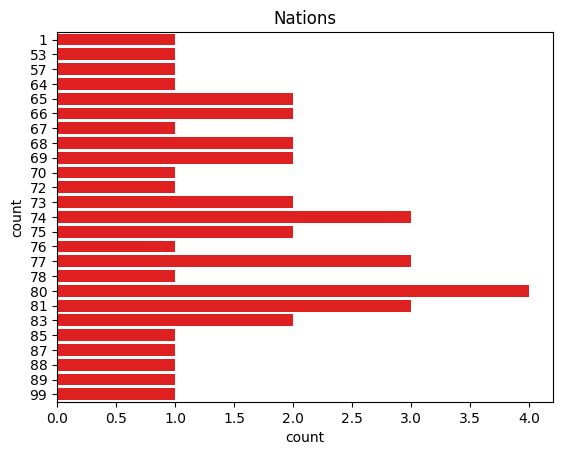

In [ ]:
sns.countplot(y=df1,data=df,color='r')
plt.title('Nations')

In [ ]:
df2=df['club'].value_counts()

Text(0.5, 1.0, 'clubs')

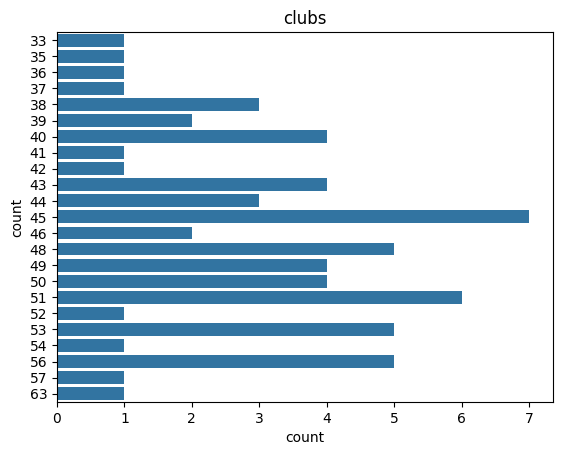

In [ ]:
sns.countplot(y=df2,data=df)
plt.title('clubs')

In [ ]:
df['market_value_million_eur'] = df['market_value_million_eur'].str.replace('M','').astype(float)

Text(0.5, 1.0, 'Transfer value')

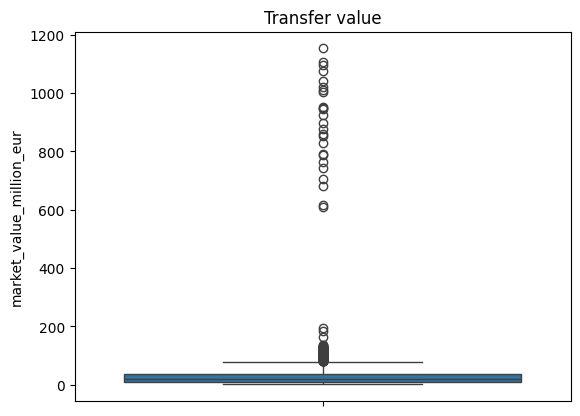

In [ ]:
sns.boxplot(y=df['market_value_million_eur'],data=df)
plt.title('Transfer value')

In [ ]:
Q1=df['market_value_million_eur'].quantile(0.25)
Q3=df['market_value_million_eur'].quantile(0.75)
IQR=Q3-Q1
lower_fence=Q1-1.5*IQR
upper_fence=Q3+1.5*IQR

In [ ]:
print(lower_fence,upper_fence)

-33.0 79.0


In [ ]:
df['market_value_million_eur']=df['market_value_million_eur'].clip(lower=lower_fence,upper=upper_fence)

Text(0.5, 1.0, 'Transfer value')

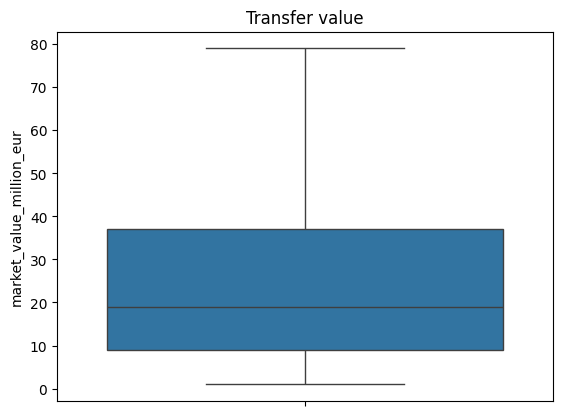

In [ ]:
sns.boxplot(y=df['market_value_million_eur'],data=df)
plt.title('Transfer value')

In [ ]:
df['age'].unique()

array([25., 30., 26., 32., 31., 22., 23., nan, 20., 27., 28., 17., 35.,
       21., 24., 29., 19., 18., 34., 33., 38., 36.])

In [ ]:
df['contract_years_left'].unique()

array([ 2.,  4., nan,  5.,  1.,  0.,  3.])

In [ ]:
df['overall_rating'].unique()

array([91., 75., nan, 90., 88., 89., 85., 84., 86., 83., 82., 74., 63.,
       78., 62., 67., 73., 80., 66., 79., 77., 72., 69., 61., 76., 68.,
       65., 64., 70., 60., 81., 87., 71.])

In [ ]:
df['age']=df['age'].fillna(df['age']).median()
df['contract_years_left']=df['contract_years_left'].fillna(df['contract_years_left']).median()
df['overall_rating']=df['overall_rating'].fillna(df['overall_rating']).median()

In [ ]:
df.isna().sum()

,0
player_name,0
age,0
nationality,0
club,0
overall_rating,0
potential_rating,0
market_value_million_eur,0
contract_years_left,0
injury_history,0
matches_played,0


In [ ]:
df_gd=pd.get_dummies(df[['nationality','club']],drop_first=True,dtype=int)
df_gd

,nationality_Argentina,nationality_Australia,nationality_Belgium,nationality_Brazil,nationality_Cameroon,nationality_Canada,nationality_Chile,nationality_Colombia,nationality_Croatia,nationality_Czech Republic,...,club_River Plate,club_Sevilla,club_Sporting CP,club_Stuttgart,club_Torino,club_Tottenham,club_Valencia,club_Villarreal,club_West Ham,club_Wolves
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df = df.drop(columns=['nationality', 'club', 'player_name'])

In [ ]:
df

,age,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,goals,assists,shots_on_target,conversion_rate,transfer_risk_level
0,25.0,75.0,92,79.0,2.0,3,28,27,16,38,71.1,Low
1,25.0,75.0,93,79.0,2.0,1,15,17,4,58,29.3,Low
2,25.0,75.0,92,79.0,2.0,1,25,22,13,88,25.0,Low
3,25.0,75.0,91,11.0,2.0,3,40,9,16,71,12.7,High
4,25.0,75.0,89,4.0,2.0,6,33,9,12,75,12.0,High
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,25.0,75.0,67,15.0,2.0,1,14,19,9,17,111.8,Low
2996,25.0,75.0,80,8.0,2.0,2,15,30,15,39,76.9,High
2997,25.0,75.0,77,16.0,2.0,0,33,1,15,84,1.2,High
2998,25.0,75.0,86,35.0,2.0,0,42,5,17,76,6.6,High


In [ ]:
df_con=df.copy()

In [ ]:
df_con

,age,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,goals,assists,shots_on_target,conversion_rate,transfer_risk_level
0,25.0,75.0,92,79.0,2.0,3,28,27,16,38,71.1,Low
1,25.0,75.0,93,79.0,2.0,1,15,17,4,58,29.3,Low
2,25.0,75.0,92,79.0,2.0,1,25,22,13,88,25.0,Low
3,25.0,75.0,91,11.0,2.0,3,40,9,16,71,12.7,High
4,25.0,75.0,89,4.0,2.0,6,33,9,12,75,12.0,High
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,25.0,75.0,67,15.0,2.0,1,14,19,9,17,111.8,Low
2996,25.0,75.0,80,8.0,2.0,2,15,30,15,39,76.9,High
2997,25.0,75.0,77,16.0,2.0,0,33,1,15,84,1.2,High
2998,25.0,75.0,86,35.0,2.0,0,42,5,17,76,6.6,High


In [ ]:
from sklearn.preprocessing import LabelEncoder
le_target = LabelEncoder()
df['transfer_risk_level'] = le_target.fit_transform(df['transfer_risk_level'])

In [ ]:
x=df_con.drop(columns='transfer_risk_level')

In [ ]:
x

,age,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,goals,assists,shots_on_target,conversion_rate
0,25.0,75.0,92,79.0,2.0,3,28,27,16,38,71.1
1,25.0,75.0,93,79.0,2.0,1,15,17,4,58,29.3
2,25.0,75.0,92,79.0,2.0,1,25,22,13,88,25.0
3,25.0,75.0,91,11.0,2.0,3,40,9,16,71,12.7
4,25.0,75.0,89,4.0,2.0,6,33,9,12,75,12.0
...,...,...,...,...,...,...,...,...,...,...,...
2995,25.0,75.0,67,15.0,2.0,1,14,19,9,17,111.8
2996,25.0,75.0,80,8.0,2.0,2,15,30,15,39,76.9
2997,25.0,75.0,77,16.0,2.0,0,33,1,15,84,1.2
2998,25.0,75.0,86,35.0,2.0,0,42,5,17,76,6.6


In [ ]:
y=df_con['transfer_risk_level']

In [ ]:
y

,transfer_risk_level
0,Low
1,Low
2,Low
3,High
4,High
...,...
2995,Low
2996,High
2997,High
2998,High


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape

(2400, 11)

In [ ]:
x_test.shape

(600, 11)

In [ ]:
y_train.shape

(2400,)

In [ ]:
y_test.shape

(600,)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler  = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)
x_train

array([[ 0.        ,  0.        , -0.50776051, ...,  1.21533283,
         0.69048962, -0.58524942],
       [ 0.        ,  0.        , -0.8134613 , ...,  0.05310725,
        -1.26417825,  0.71816876],
       [ 0.        ,  0.        ,  0.81694289, ..., -0.91541406,
         0.34554823, -0.38426884],
       ...,
       [ 0.        ,  0.        , -1.6286634 , ..., -0.52800554,
        -0.15270044, -0.40643581],
       [ 0.        ,  0.        , -0.50776051, ...,  0.05310725,
         1.64866015, -0.34584608],
       [ 0.        ,  0.        , -0.71156104, ..., -0.14059701,
         0.76714326, -0.48475913]])

In [ ]:
from imblearn.combine import SMOTETomek
smt = SMOTETomek(random_state=42)
x_train_res, y_train_res = smt.fit_resample(x_train, y_train)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train_res,y_train_res)
y_pred=model.predict(x_test)


In [ ]:
from sklearn.metrics import accuracy_score
score=accuracy_score(y_test,y_pred)

In [ ]:
score

0.8033333333333333

              precision    recall  f1-score   support

        High       0.78      0.94      0.85       358
         Low       0.88      0.60      0.71       242

    accuracy                           0.80       600
   macro avg       0.83      0.77      0.78       600
weighted avg       0.82      0.80      0.79       600



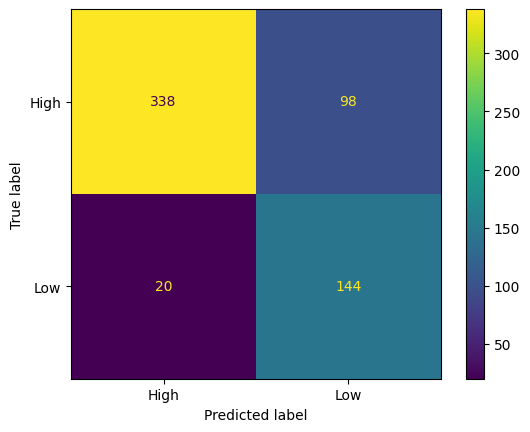

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print(classification_report(y_pred, y_test, target_names=['High','Low']))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['High','Low'])
plt.show()

In [ ]:
joblib.dump(model,'model_fw.pkl')
joblib.dump(scaler,'scaler_fw.pkl')
joblib.dump(le_target,'encoder_fw.pkl')

['encoder_fw.pkl']

In [ ]:
from google.colab import files
files.download('model_fw.pkl')
files.download('scaler_fw.pkl')
files.download('encoder_fw.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>